In [1]:
import os
import pandas as pd
from glob import glob
from onekey_algo import get_param_in_cwd
from onekey_algo.custom.utils import print_join_info

root = get_param_in_cwd('radio_dir')
task_type = 'L'
label_data = pd.read_csv(os.path.join(root, f'{task_type}.csv'))
label_data['ID'] = label_data['ID'].map(lambda x: f"{x}.jpg")
label_data

,ID,label,group
0,白璨瑀202003-202501.jpg,0.0,train
1,边英杰202402-202502.jpg,0.0,train
2,曹骥201407-201701.jpg,2.0,train
3,常怀城201411-201709.jpg,1.5,train
4,陈博201803-202302.jpg,7.5,train
...,...,...,...
301,张颖泰20230525-20241024.jpg,4.5,test
302,赵恩笛20230915-20250105.jpg,2.0,test
303,赵鹏20200521-20241107.jpg,1.0,test
304,赵志男20230401-20241112.jpg,0.0,test


In [2]:
import os
from glob import glob
import pandas as pd
import cv2
from PIL import Image
import numpy as np
import os
from onekey_algo import get_param_in_cwd


Csamples = glob(os.path.join(root, 'jpg', '颈椎' if task_type == 'C' else '腰椎', '*', '冠状位', '*'))
Ssamples = glob(os.path.join(root, 'jpg', '颈椎' if task_type == 'C' else '腰椎', '*', '矢状位', '*'))
def merge_gray_images(output_path, *ipath, resize=(299, 299)):
    if len(ipath) == 1:
        image_arrs = [Image.open(ip).convert('L').resize(resize) for ip in ipath] * 3
    else:
        image_arrs = [np.array(Image.open(ip).convert('L').resize(resize)) for ip in ipath]
        image_arrs.append((image_arrs[1] + image_arrs[0]) // 2)
    merged_image = np.dstack(image_arrs)
    np.save(output_path, merged_image)

save2 = os.path.join(root, task_type)
os.makedirs(save2, exist_ok=True)
for sample in zip(Csamples, Ssamples):
    opath = os.path.join(save2, os.path.basename(os.path.dirname(os.path.dirname(sample[0]))))
#     print(sample)
    merge_gray_images(opath, *sample)

D:\\20251014-fenghexin_fuxin\L\崔磊20200606-20220308.npy


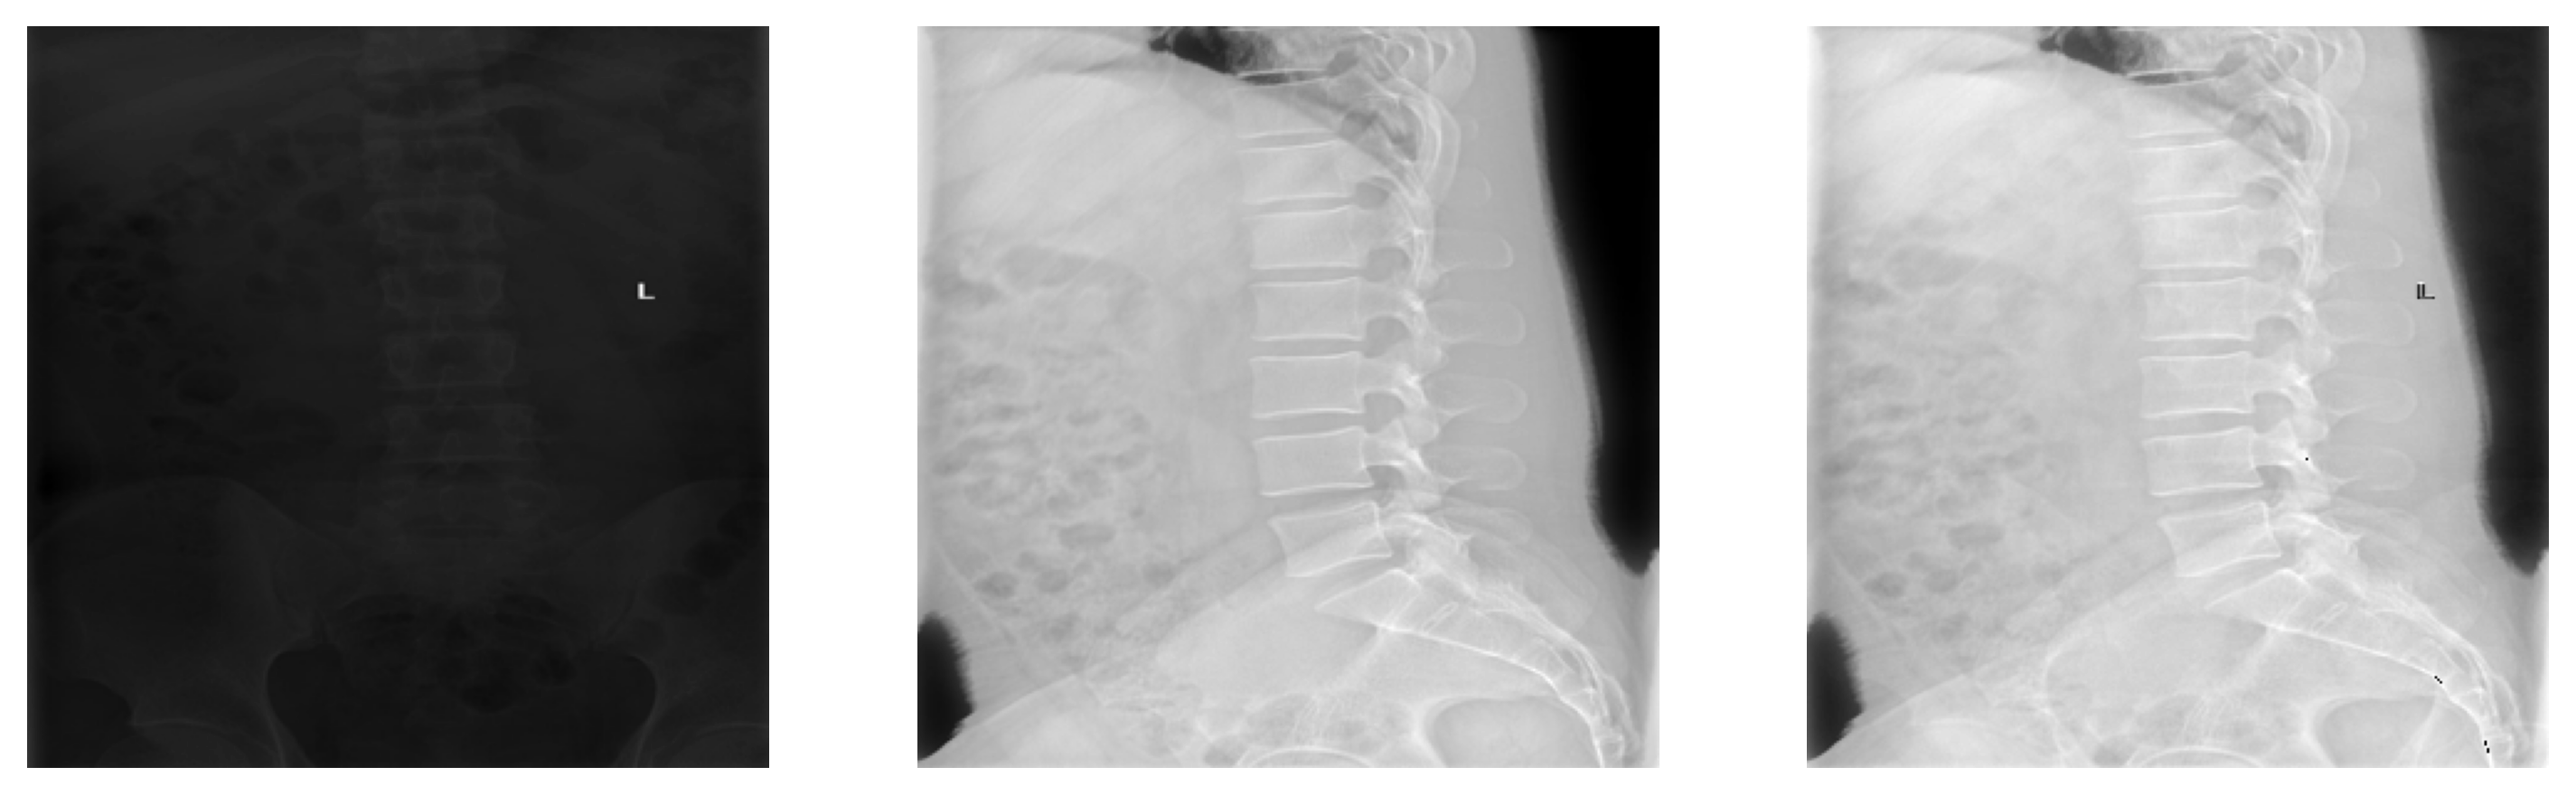

D:\\20251014-fenghexin_fuxin\L\郭凯20210914-20231213.npy


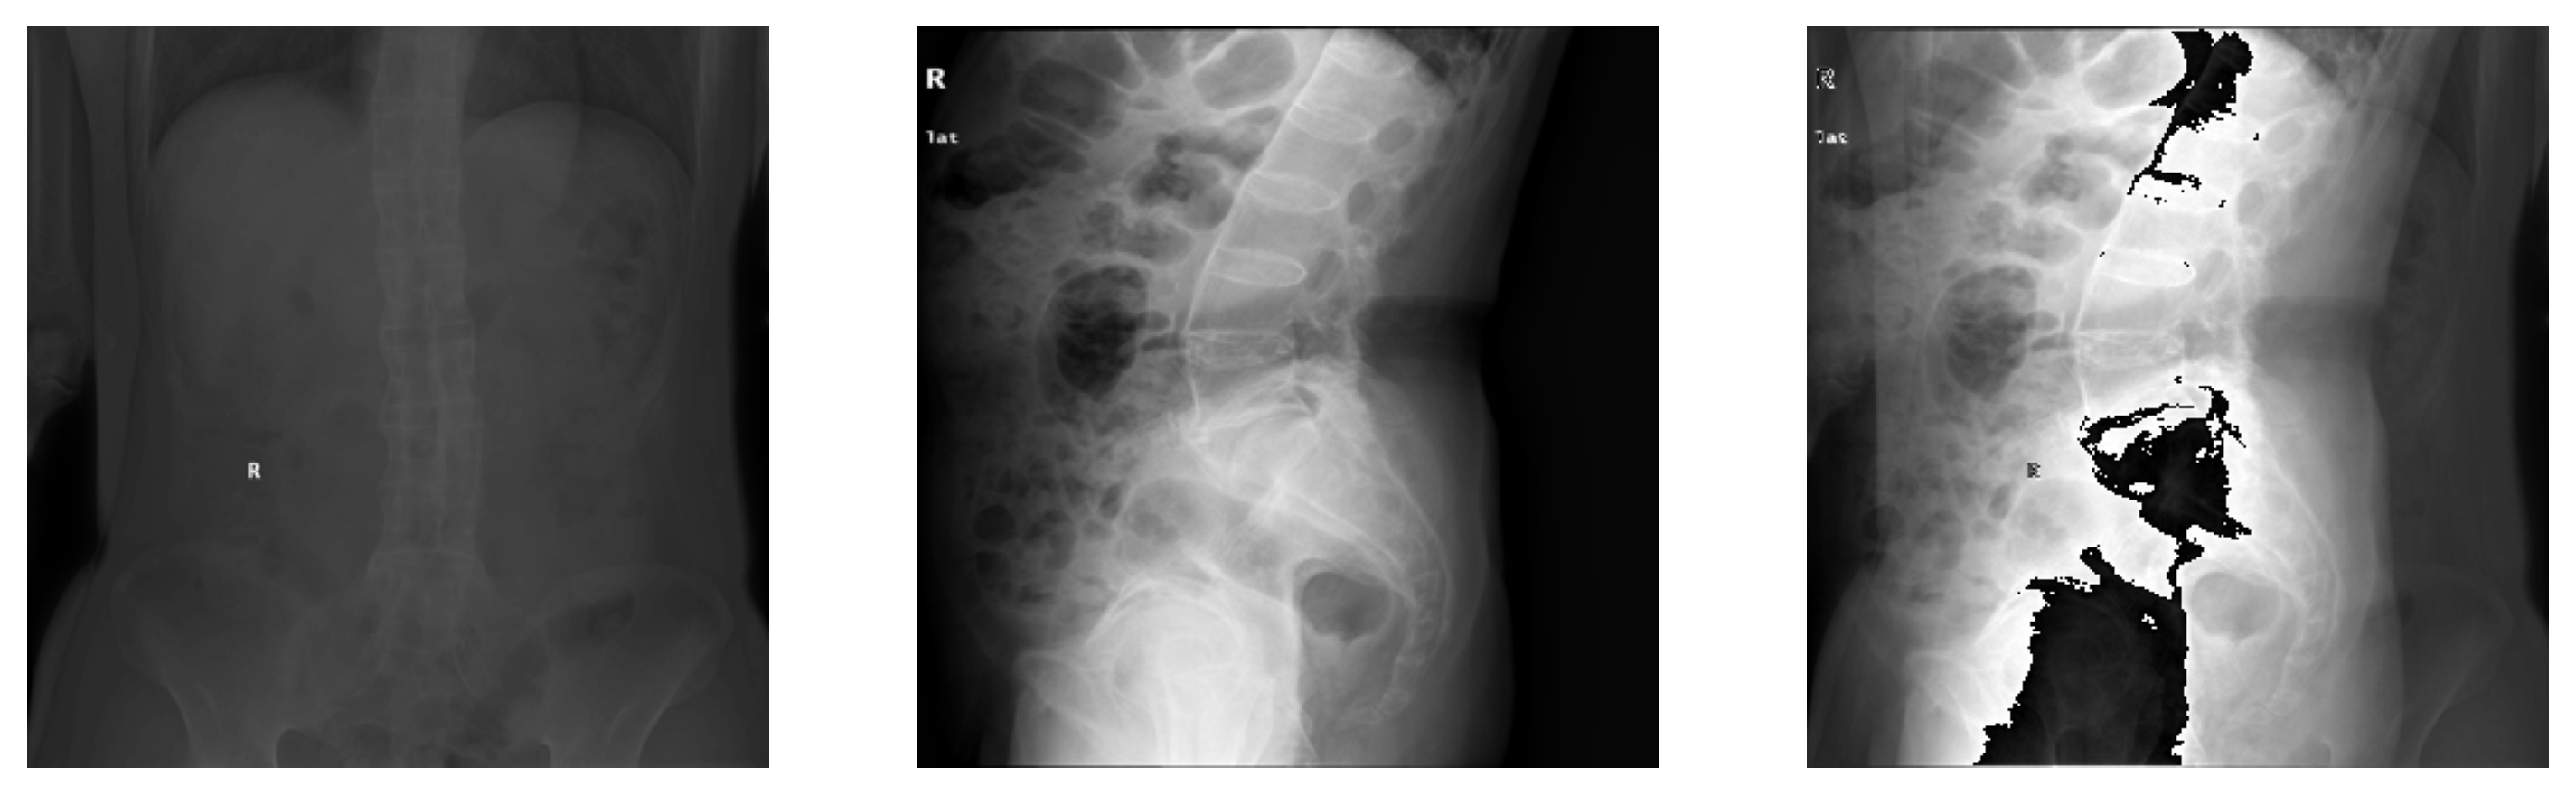

D:\\20251014-fenghexin_fuxin\L\牛大勇20220926-20231007.npy


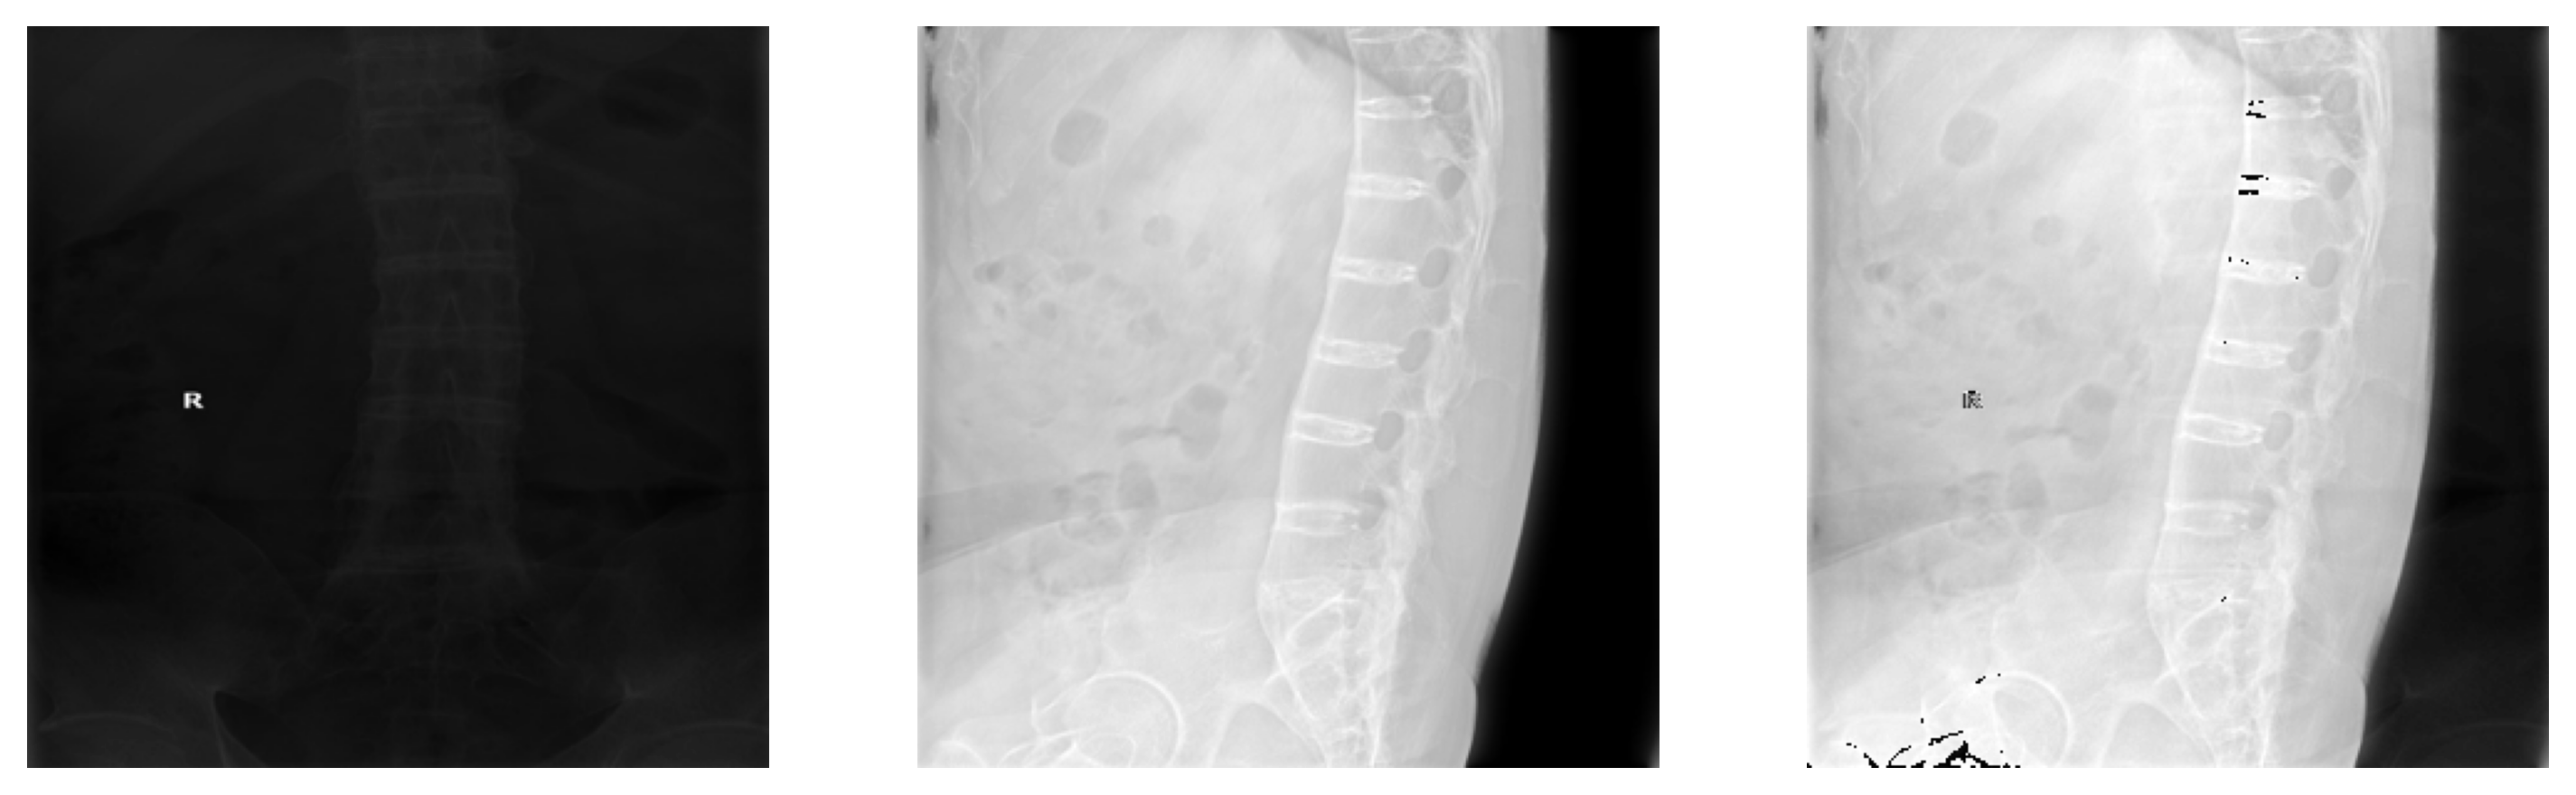

D:\\20251014-fenghexin_fuxin\L\庞浩20220123-20230213.npy


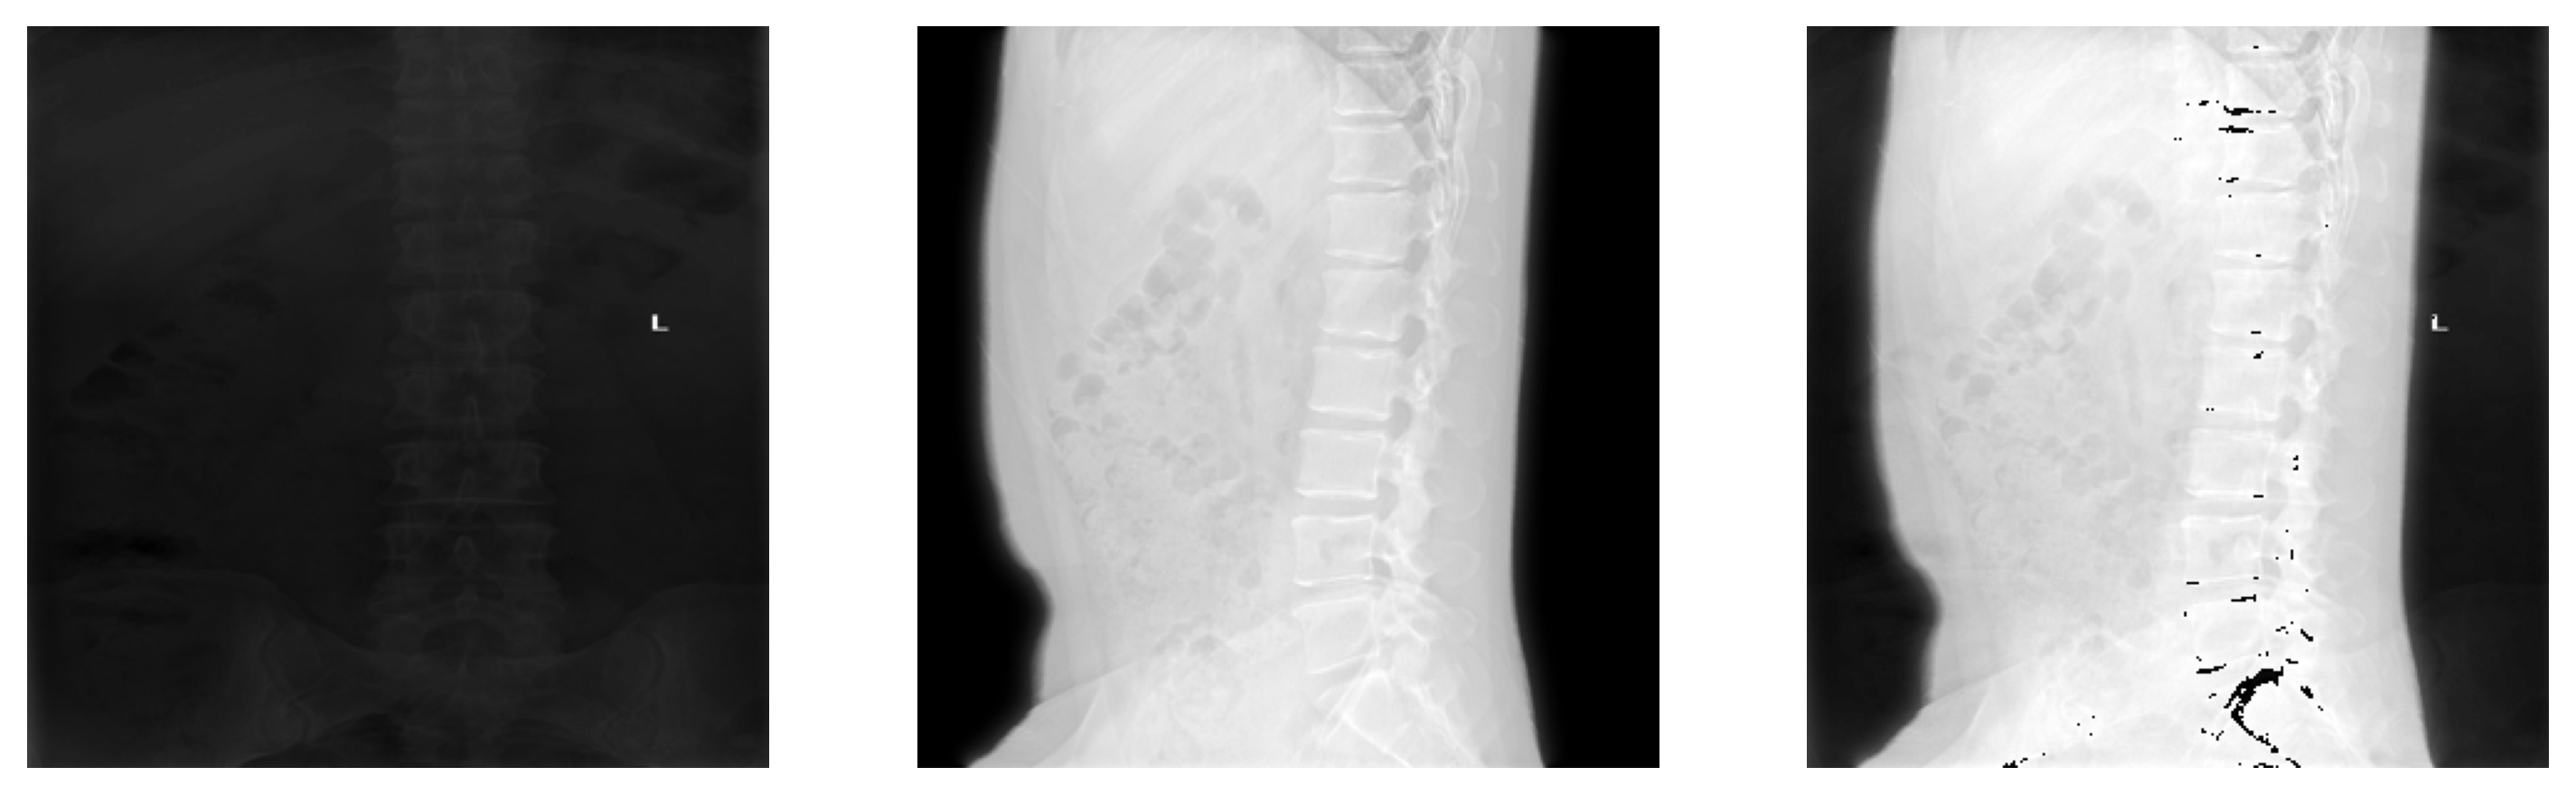

In [3]:
import random
import matplotlib.pyplot as plt
from onekey_algo.datasets.image_loader import default_loader

for group in [get_param_in_cwd('modals')]:
    images = glob(os.path.join(root, f'{task_type}/*.npy'))
    random.shuffle(images)

    for sample in images[:4]:
        print(sample)
        img = default_loader(sample)
        num_channels = img.shape[-1]
        fig, axes = plt.subplots(1, num_channels, figsize=(4 * (num_channels), 4), facecolor='white')
        img = np.array(img)
        if num_channels == 1:
            axes.imshow(img[..., 0], cmap='gray')
            axes.axis('off')
        else:
            for i in range(num_channels):
                axes[i].imshow(img[..., i], cmap='gray')
                axes[i].axis('off')
        plt.show()

In [1]:
import pandas as pd
import os
from onekey_algo.custom.components.comp2 import split_dataset4sol
from onekey_algo import get_param_in_cwd
import math

task_type = 'L'
root = get_param_in_cwd('radio_dir')
label_data = pd.read_csv(os.path.join(root, f'{task_type}.csv'))
label_data['ID'] = label_data['ID'].map(lambda x: f"{x}.jpg")
label_data['label'] = label_data['label'].map(lambda x: math.log(x+1))
# label_data['group'] = 'train'
# rt = split_dataset4sol(label_data, label_data['label'], cv=False, n_trails=1, test_size=0.15, save_dir='.', shuffle=True)
# label_data = pd.concat(rt[0], axis=0)
train_data = label_data[label_data['group'] == 'train']
test_data = label_data[label_data['group'] != 'train']
rt = split_dataset4sol(train_data, train_data['label'], cv=False, n_trails=10, test_size=0.3, save_dir='.', shuffle=True,
                       map_ext='.npy')

for idx, (train, val) in enumerate(rt):
    val['group'] = 'val'
    all_data = pd.concat([train, val, test_data], axis=0)
# #     all_data['ID'] = all_data['ID'].map(lambda x: x if str(x).endswith('.nii.gz') else f"{x}.nii.gz")
    all_data.to_csv(f'split_info/label-RND-{idx}.csv', index=False, encoding='utf-8-sig')
    display(all_data['group'].value_counts())
    all_data['ID'] = all_data['ID'].map(lambda x: x.replace('.jpg', '.npy'))
    all_data[all_data['group'] == 'train'][['ID', 'label']].to_csv(f'split_info/train-RND-{idx}.txt', sep='\t', index=False, header=False)
    all_data[all_data['group'] != 'train'][['ID', 'label']].to_csv(f'split_info/val-RND-{idx}.txt', sep='\t', index=False, header=False)

train    178
val       77
test      51
Name: group, dtype: int64

train    178
val       77
test      51
Name: group, dtype: int64

train    178
val       77
test      51
Name: group, dtype: int64

train    178
val       77
test      51
Name: group, dtype: int64

train    178
val       77
test      51
Name: group, dtype: int64

train    178
val       77
test      51
Name: group, dtype: int64

train    178
val       77
test      51
Name: group, dtype: int64

train    178
val       77
test      51
Name: group, dtype: int64

train    178
val       77
test      51
Name: group, dtype: int64

train    178
val       77
test      51
Name: group, dtype: int64